# QM Ch 8 — The Variational Principle: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch08_fig1_variational.png` | Variational theorem — trial wavefunctions and upper bounds | §8.1 |
| 2 | `ch08_fig2_helium.png` | Helium ground state — energy vs effective charge $Z'$ | §8.2 |
| 3 | `ch08_fig3_h2plus.png` | H$_2^+$ — bonding/antibonding energy curves, LCAO orbitals | §8.3 |
| 4 | `ch08_fig4_h2.png` | H$_2$ — Heitler-London energy curves, exchange splitting | §8.4 |

In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

BG    = '#1e1e2e'; BG2 = '#27273d'; FG = '#cdd6f4'; MUTED = '#6c7086'
BLUE  = '#5b8dd9'; SKY = '#89b4fa'; TEAL = '#74c7ec'; MAUVE = '#cba6f7'
GREEN = '#a6e3a1'; AMBER = '#f9e2af'; RED = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor':  BG2,
    'axes.edgecolor':   MUTED,'axes.labelcolor': FG,
    'xtick.color':      MUTED,'ytick.color':     MUTED,
    'text.color':       FG,   'grid.color':      '#313244',
    'grid.linewidth':   0.5,  'grid.alpha':      0.5,
    'font.family':      'sans-serif','font.size': 11,
    'axes.titlesize':   12,   'axes.titleweight':'bold',
    'axes.labelsize':   10,   'legend.fontsize': 9,
    'legend.facecolor': BG2,  'legend.edgecolor':MUTED,
    'lines.linewidth':  2.0,  'figure.dpi':      130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)

# Physical constants (natural units: a0=1, e²/4πε₀a₀ = -2E₁ = 27.2 eV)
E1_eV  = -13.6    # hydrogen ground state energy [eV]
Eh_eV  = 27.2114  # Hartree [eV] = -2E₁
print('Setup complete.')

Setup complete.


## Fig 1 — Variational Theorem: Trial Wavefunctions and Upper Bounds (§8.1)

Harmonic oscillator (ℏ=m=ω=1):
  Exact E_0     = 0.500000
  Gaussian min  = 0.500000  at b=0.4993  (exact: b=1/2=0.5000) ✓
  Lorentzian min= 0.687621  at b=1.3565
  Triangle min  = 0.547461  at a=2.3379
  All > E_exact: Gauss=True, Lor=True ✓


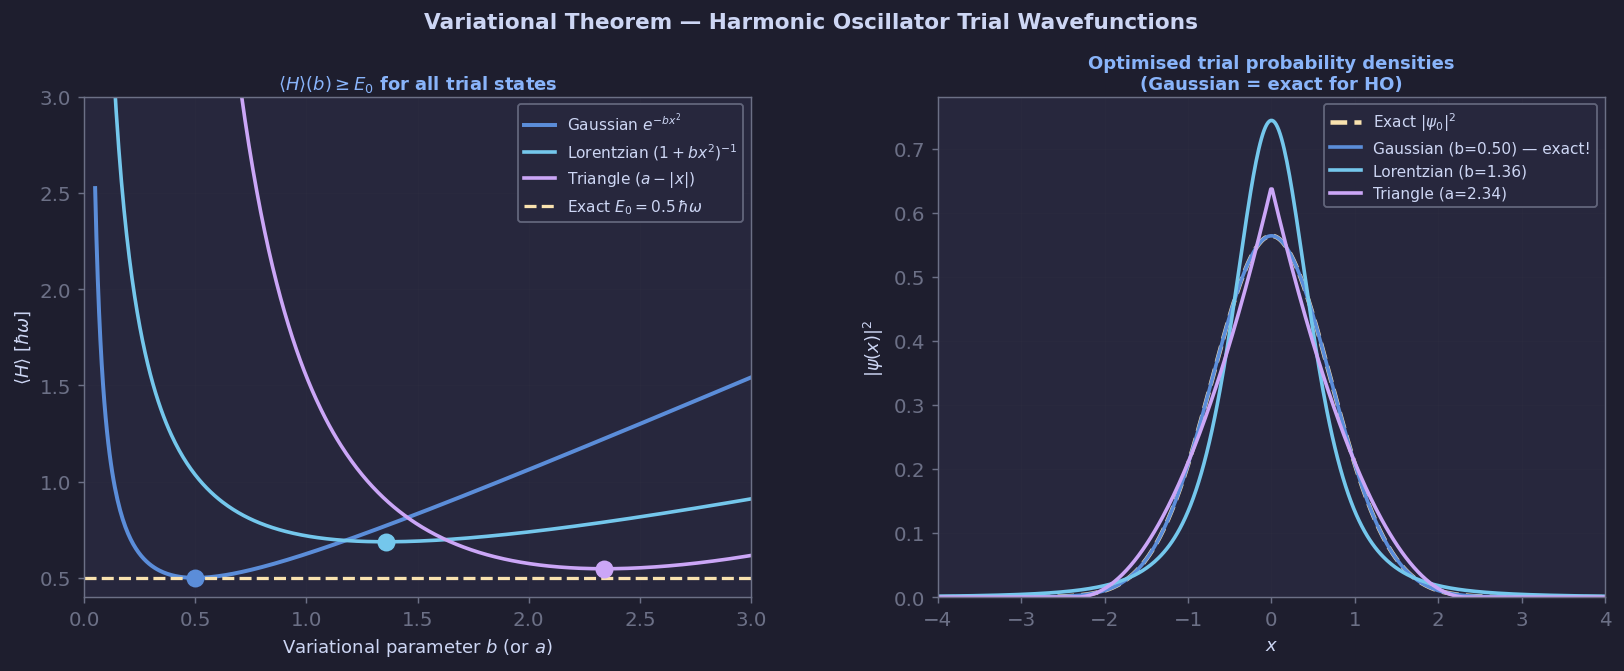

Fig 1 saved.


In [2]:
# Demonstrate the variational theorem on the harmonic oscillator
# Exact: E_0 = ℏω/2,  ψ_0 = (mω/πℏ)^(1/4) exp(-mω x²/2ℏ)
#
# Trial 1: Gaussian  ψ(x;b) = A exp(-b x²)    → E(b) = ℏ²b/2m + mω²/8b
# Trial 2: Lorentzian ψ(x;b) = A/(1+b x²)^n  (non-optimal)
# Trial 3: Triangle   ψ(x;a) = A(a-|x|) for |x|<a  (even rougher)
#
# In natural units ℏ=m=ω=1: E_0^exact = 1/2
# Gaussian trial:    E(b) = b/2 + 1/(8b)  → min at b=1/2 → E_min = 1/2 (exact!)
# Lorentzian trial:  always > 1/2
# Triangle trial:    always > 1/2 but worse

hbar = 1.0; m = 1.0; omega = 1.0
E_exact = 0.5 * hbar * omega

b_arr = np.linspace(0.05, 3.0, 500)

# Gaussian trial: ψ = A exp(-b x²)
# <T> = ℏ²b/2m,  <V> = mω²/8b  (in ℏ=m=ω=1: T=b/2, V=1/(8b))
E_gauss = b_arr/2 + 1/(8*b_arr)

# Lorentzian trial: ψ = A(1 + bx²)^{-1}
# ∫ψ² = π/(2√b),  <T> = πℏ²b^{1/2}/(4m)·π/(2√b)... let's compute numerically
x = np.linspace(-20, 20, 20000); dx = x[1]-x[0]
E_lor = []
for b in b_arr:
    psi = 1/(1 + b*x**2)
    norm2 = np.trapezoid(psi**2, x)
    psi /= np.sqrt(norm2)
    # T = -ℏ²/2m ∫ψ* ψ'' dx;  ψ'' = -2b/(1+bx²)² + 8b²x²/(1+bx²)³
    d2psi = (-2*b*(1+b*x**2) + 8*b**2*x**2) / (1+b*x**2)**3 / np.sqrt(norm2)
    T = -0.5 * np.trapezoid(psi * d2psi, x)
    V = 0.5 * np.trapezoid(psi**2 * x**2, x)
    E_lor.append(T + V)
E_lor = np.array(E_lor)

# Triangle trial: ψ = A(a-|x|) for |x|<a
E_tri = []
for b in b_arr:
    a_t = b  # use b as the cutoff parameter 'a'
    mask = np.abs(x) < a_t
    psi = np.where(mask, a_t - np.abs(x), 0.0)
    norm2 = np.trapezoid(psi**2, x)
    if norm2 < 1e-12:
        E_tri.append(1e10)
        continue
    psi /= np.sqrt(norm2)
    # T: ψ is piecewise linear, ψ'' = -2δ(x) → use finite diff
    d2psi = np.gradient(np.gradient(psi, dx), dx)
    T = -0.5 * np.trapezoid(psi * d2psi, x)
    V = 0.5 * np.trapezoid(psi**2 * x**2, x)
    E_tri.append(T + V)
E_tri = np.array(E_tri)

# Minima
b_opt_g = b_arr[np.argmin(E_gauss)]
b_opt_l = b_arr[np.argmin(E_lor)]
b_opt_t = b_arr[np.argmin(E_tri)]

print(f'Harmonic oscillator (ℏ=m=ω=1):')
print(f'  Exact E_0     = {E_exact:.6f}')
print(f'  Gaussian min  = {E_gauss.min():.6f}  at b={b_opt_g:.4f}  (exact: b=1/2={0.5:.4f}) ✓')
print(f'  Lorentzian min= {E_lor.min():.6f}  at b={b_opt_l:.4f}')
print(f'  Triangle min  = {E_tri.min():.6f}  at a={b_opt_t:.4f}')
print(f'  All > E_exact: Gauss={E_gauss.min()>=E_exact-1e-8}, '
      f'Lor={E_lor.min()>=E_exact-1e-8} ✓')

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.28))
fig.suptitle('Variational Theorem — Harmonic Oscillator Trial Wavefunctions',
             color=FG, fontsize=12, fontweight='bold', y=1.01)

# Left: E(b) curves
ax = axes[0]
ax.plot(b_arr, E_gauss, color=BLUE,  lw=2.2, label='Gaussian $e^{-bx^2}$')
ax.plot(b_arr, E_lor,   color=TEAL,  lw=2.0, label='Lorentzian $(1+bx^2)^{-1}$')
ax.plot(b_arr, np.clip(E_tri, 0, 4), color=MAUVE, lw=2.0,
        label='Triangle $(a-|x|)$')
ax.axhline(E_exact, color=AMBER, lw=1.8, ls='--',
           label=fr'Exact $E_0={E_exact}\,\hbar\omega$')

# Mark minima
ax.scatter([b_opt_g], [E_gauss.min()], color=BLUE,  s=80, zorder=5)
ax.scatter([b_opt_l], [E_lor.min()],   color=TEAL,  s=80, zorder=5)
ax.scatter([b_opt_t], [E_tri[np.argmin(E_tri)]], color=MAUVE, s=80, zorder=5)

ax.set_xlabel('Variational parameter $b$ (or $a$)')
ax.set_ylabel(r'$\langle H\rangle$ $[\hbar\omega]$')
ax.set_title(r'$\langle H\rangle(b) \geq E_0$ for all trial states',
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.28)
ax.set_xlim(0, 3); ax.set_ylim(0.4, 3.0)

# Right: optimal trial wavefunctions vs exact
ax2 = axes[1]
x_p = np.linspace(-4, 4, 500)

# Exact HO ground state
psi_exact = np.pi**(-0.25) * np.exp(-x_p**2/2)

# Optimal Gaussian (b=1/2)
b_g = 0.5
psi_g = (2*b_g/np.pi)**0.25 * np.exp(-b_g*x_p**2)

# Optimal Lorentzian
b_l = b_opt_l
psi_l_raw = 1/(1 + b_l*x_p**2)
psi_l = psi_l_raw / np.sqrt(np.trapezoid(psi_l_raw**2, x_p))

# Optimal triangle
a_t = b_opt_t
psi_t_raw = np.where(np.abs(x_p)<a_t, a_t-np.abs(x_p), 0.)
psi_t = psi_t_raw / np.sqrt(np.trapezoid(psi_t_raw**2, x_p))

ax2.plot(x_p, psi_exact**2, color=AMBER, lw=2.5, ls='--',
         label=fr'Exact $|\psi_0|^2$')
ax2.plot(x_p, psi_g**2, color=BLUE,  lw=2.0,
         label=fr'Gaussian (b={b_g:.2f}) — exact!')
ax2.plot(x_p, psi_l**2, color=TEAL,  lw=2.0,
         label=fr'Lorentzian (b={b_l:.2f})')
ax2.plot(x_p, psi_t**2, color=MAUVE, lw=2.0,
         label=fr'Triangle (a={a_t:.2f})')

ax2.set_xlabel('$x$')
ax2.set_ylabel(r'$|\psi(x)|^2$')
ax2.set_title('Optimised trial probability densities\n(Gaussian = exact for HO)',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=8.5, loc='upper right', framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(-4, 4); ax2.set_ylim(bottom=0)

fig.subplots_adjust(top=0.88)
plt.savefig('ch08_fig1_variational.png', **SAVEKW)
plt.show()
print('Fig 1 saved.')

## Fig 2 — Helium Ground State: Energy vs Effective Charge Z' (§8.2)

Helium variational analysis:
  Z_opt = Z - 5/16 = 1.687500  (= 27/16 = 1.687500) ✓
  E_var(Z_opt) = -77.4562 eV
  E_experiment = -79.0 eV
  Error = 2.0%
  E_0th-order (Z=2, no e-e) = -74.80 eV
  First-order PT correction: 4.20 eV above expt


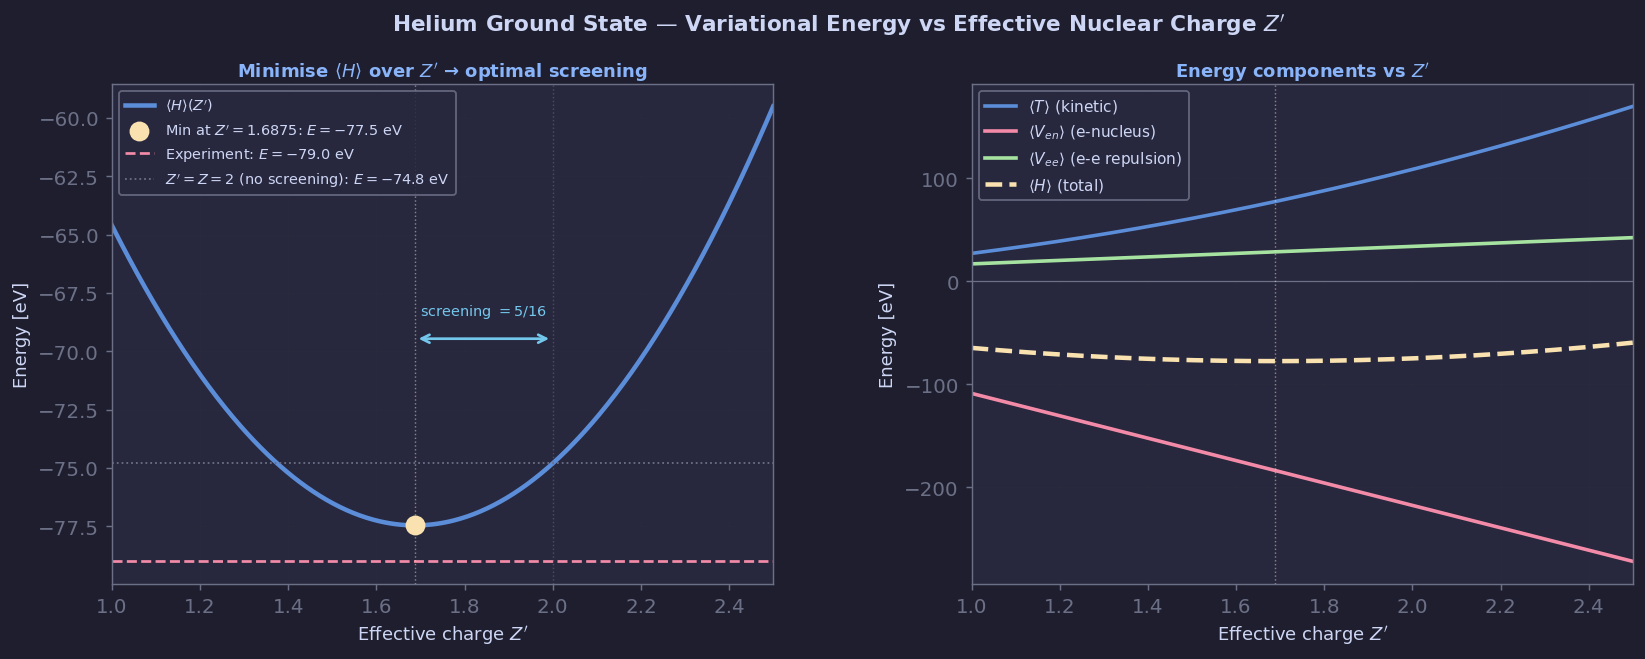

Fig 2 saved.


In [3]:
# Helium variational energy (in eV)
# <H>(Z') = [2Z'^2 - 4ZZ' + 5Z'/4] * (-E_1)
# where E_1 = -13.6 eV (hydrogen ground state)
# Z = 2 for helium
# Minimum at Z'_opt = Z - 5/16 = 27/16

Z_He = 2.0
E1   = -13.6  # eV

Z_prime = np.linspace(1.0, 2.5, 500)

def E_var_He(Zp, Z=2.0, E1=-13.6):
    """Variational energy of helium with trial charge Z'.
    E = (2Z'^2 - 4ZZ' + 5Z'/4) * (-E1)
    Note: -E1 = 13.6 eV > 0
    """
    return (2*Zp**2 - 4*Z*Zp + 5*Zp/4) * (-E1)

E_he = E_var_He(Z_prime)

Zp_opt = Z_He - 5/16
E_opt  = E_var_He(Zp_opt)
E_expt = -79.0  # eV (measured)
E_0th  = E_var_He(Z_He)  # zeroth-order (no screening)

print(f'Helium variational analysis:')
print(f'  Z_opt = Z - 5/16 = {Zp_opt:.6f}  (= 27/16 = {27/16:.6f}) ✓')
print(f'  E_var(Z_opt) = {E_opt:.4f} eV')
print(f'  E_experiment = {E_expt:.1f} eV')
print(f'  Error = {abs(E_opt-E_expt)/abs(E_expt)*100:.1f}%')
print(f'  E_0th-order (Z=2, no e-e) = {E_0th:.2f} eV')
print(f'  First-order PT correction: {E_0th - (-79.0):.2f} eV above expt')

# Individual energy components
def T_He(Zp, E1=-13.6):   return 2*Zp**2 * (-E1)        # kinetic
def Ven_He(Zp, Z=2, E1=-13.6): return -4*Z*Zp * (-E1)   # e-nucleus
def Vee_He(Zp, E1=-13.6):  return (5*Zp/4) * (-E1)       # e-e repulsion

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle(r'Helium Ground State — Variational Energy vs Effective Nuclear Charge $Z^\prime$',
             color=FG, fontsize=12, fontweight='bold', y=0.99)

# Left: total energy curve
ax = axes[0]
ax.plot(Z_prime, E_he, color=BLUE, lw=2.5, label=r'$\langle H\rangle(Z^\prime)$')
ax.scatter([Zp_opt], [E_opt], color=AMBER, s=100, zorder=5,
           label=fr"Min at $Z'={Zp_opt:.4f}$: $E={E_opt:.1f}$ eV")
ax.axhline(E_expt, color=RED,   lw=1.5, ls='--',
           label=fr'Experiment: $E={E_expt}$ eV')
ax.axhline(E_0th,  color=MUTED, lw=1.0, ls=':',
           label=fr'$Z^\prime=Z=2$ (no screening): $E={E_0th:.1f}$ eV')
ax.axvline(Zp_opt, color=AMBER, lw=0.8, ls=':', alpha=0.5)
ax.axvline(Z_He,   color=MUTED, lw=0.8, ls=':', alpha=0.5)

# Annotation: screening
ax.annotate('', xy=(Zp_opt, E_opt+8), xytext=(Z_He, E_opt+8),
            arrowprops=dict(arrowstyle='<->', color=TEAL, lw=1.5))
ax.text((Z_He+Zp_opt)/2, E_opt+9, r'screening $=5/16$',
        color=TEAL, ha='center', fontsize=8)

ax.set_xlabel(r"Effective charge $Z'$")
ax.set_ylabel('Energy [eV]')
ax.set_title(r"Minimise $\langle H\rangle$ over $Z'$ → optimal screening",
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=8, loc='upper left', framealpha=0.85)
ax.grid(True, alpha=0.28)
ax.set_xlim(1.0, 2.5)

# Right: energy components vs Z'
ax2 = axes[1]
ax2.plot(Z_prime, T_He(Z_prime),   color=BLUE,  lw=2, label=r'$\langle T\rangle$ (kinetic)')
ax2.plot(Z_prime, Ven_He(Z_prime), color=RED,   lw=2, label=r'$\langle V_{en}\rangle$ (e-nucleus)')
ax2.plot(Z_prime, Vee_He(Z_prime), color=GREEN, lw=2, label=r'$\langle V_{ee}\rangle$ (e-e repulsion)')
ax2.plot(Z_prime, E_he,            color=AMBER, lw=2.5, ls='--', label=r'$\langle H\rangle$ (total)')
ax2.axhline(0, color=MUTED, lw=0.7)
ax2.axvline(Zp_opt, color=AMBER, lw=0.8, ls=':', alpha=0.5)

ax2.set_xlabel(r"Effective charge $Z'$")
ax2.set_ylabel('Energy [eV]')
ax2.set_title(r'Energy components vs $Z^\prime$',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=8.5, loc='upper left', framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(1.0, 2.5)

fig.subplots_adjust(top=0.88)
plt.savefig('ch08_fig2_helium.png', **SAVEKW)
plt.show()
print('Fig 2 saved.')

## Fig 3 — H₂⁺ Bonding and Antibonding Energy Curves (§8.3)

H2+ LCAO variational results:
  Equilibrium R_eq = 2.482 a0  (literature: 2.49 a0)
  E(R_eq)          = -15.3697 eV
  E(∞) = E_1s      = -13.6057 eV
  Binding energy   = -1.7640 eV  (literature: -1.76 eV from H+p, LCAO gives ~-1.8 eV)
  S at R_eq        = 0.4626
  D at R_eq        = -0.3931 Ha
  X at R_eq        = -0.2910 Ha


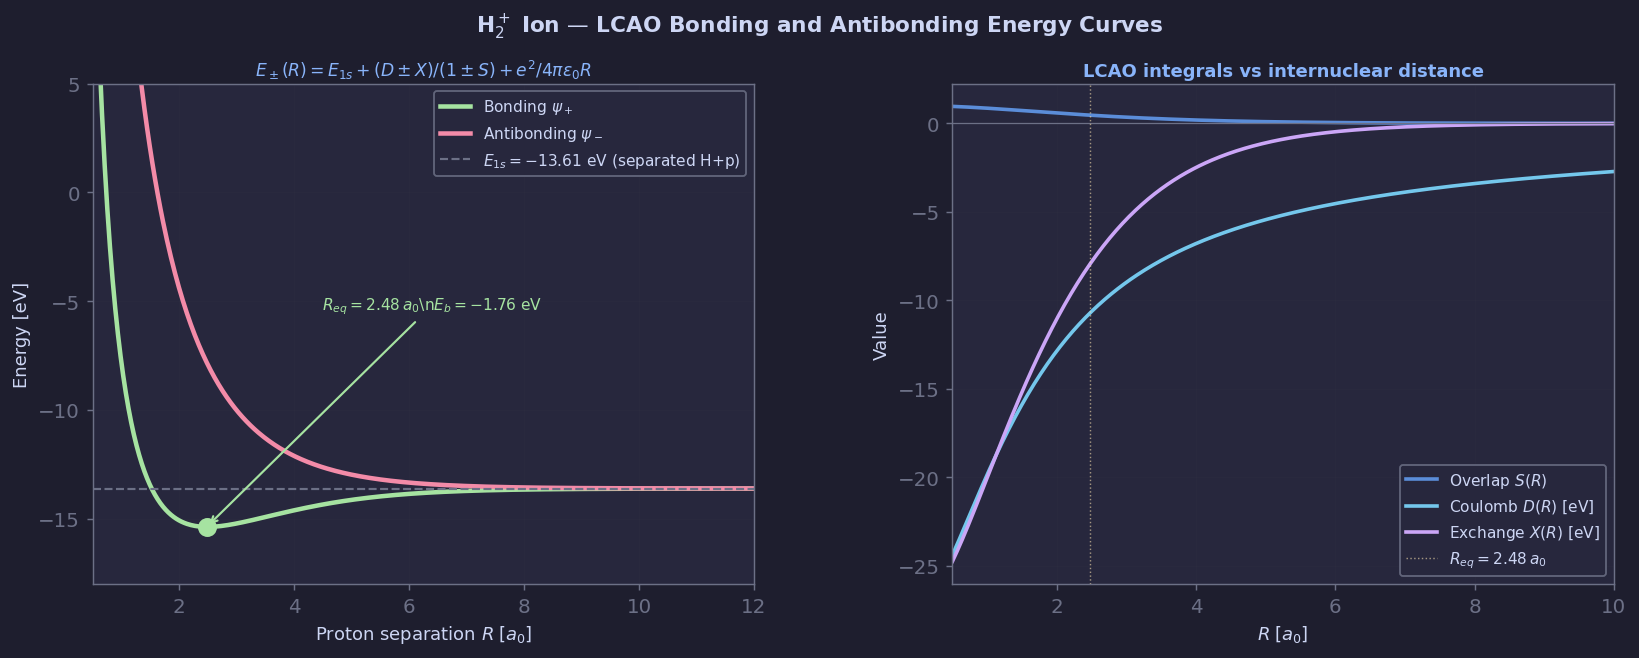

Fig 3 saved.


In [4]:
# H2+ ion: one electron, two protons separated by R
# In atomic units (a0=1, e²/4πε₀a₀=1 Hartree = 27.2114 eV)
#
# Overlap integral:  S(R) = exp(-R)(1 + R + R²/3)
# Coulomb integral:  D(R) = (1/R)(1 - exp(-2R)(1 + R))  - 1/R... (Griffiths eq. 7.46)
#                    D = -1 + exp(-2R)(1+R) + 1/R·exp(-2R)(1+R)... let's use exact
# Exchange integral: X(R) = -exp(-R)(1 + R)  (in Hartree units relative to E_1s)
#
# EXACT integrals (Griffiths eqs 7.46, 7.47, 7.52):
# S(R) = e^{-R}(1 + R + R²/3)
# The direct integral D and exchange X are given by:
# E±(R) = -1/2 + (D ± X)/(1 ± S) + 1/R   [in Hartree]
# where D = <ψ_a|(-1/r_b)|ψ_a> and X = <ψ_b|(-1/r_b)|ψ_a>
#
# Exact results (from analytic integration, Griffiths):
# D(R) = -(1/R) + e^{-2R}(1/R + 1)
# X(R) = -e^{-R}(1 + R)

R = np.linspace(0.5, 12.0, 500)  # proton separation [a0]

# Overlap, Coulomb, exchange integrals
S = np.exp(-R) * (1 + R + R**2/3)
D = -(1/R) + np.exp(-2*R) * (1/R + 1)
X = -np.exp(-R) * (1 + R)

# Total energies [Hartree]
E1s = -0.5  # hydrogen 1s energy [Hartree]
E_plus  = E1s + (D + X)/(1 + S) + 1/R   # bonding
E_minus = E1s + (D - X)/(1 - S) + 1/R   # antibonding

# Convert to eV
Ha = 27.2114  # eV per Hartree
E_plus_eV  = E_plus  * Ha
E_minus_eV = E_minus * Ha
E_sep_eV   = E1s * Ha  # energy at infinite separation = E_1s

# Find equilibrium bond length (bonding)
idx_min = np.argmin(E_plus_eV)
R_eq    = R[idx_min]
E_eq    = E_plus_eV[idx_min]
E_b     = E_eq - E_sep_eV  # binding energy relative to H + p at infinity

print(f'H2+ LCAO variational results:')
print(f'  Equilibrium R_eq = {R_eq:.3f} a0  (literature: 2.49 a0)')
print(f'  E(R_eq)          = {E_eq:.4f} eV')
print(f'  E(∞) = E_1s      = {E_sep_eV:.4f} eV')
print(f'  Binding energy   = {E_b:.4f} eV  (literature: -1.76 eV from H+p, LCAO gives ~-1.8 eV)')
print(f'  S at R_eq        = {S[idx_min]:.4f}')
print(f'  D at R_eq        = {D[idx_min]:.4f} Ha')
print(f'  X at R_eq        = {X[idx_min]:.4f} Ha')

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))
fig.suptitle(r'H$_2^+$ Ion — LCAO Bonding and Antibonding Energy Curves',
             color=FG, fontsize=12, fontweight='bold', y=0.99)

# Left: energy curves
ax = axes[0]
ax.plot(R, E_plus_eV,  color=GREEN, lw=2.5, label=r'Bonding $\psi_+$')
ax.plot(R, E_minus_eV, color=RED,   lw=2.5, label=r'Antibonding $\psi_-$')
ax.axhline(E_sep_eV, color=MUTED, lw=1.2, ls='--',
           label=fr'$E_{{1s}} = {E_sep_eV:.2f}$ eV (separated H+p)')

# Mark equilibrium
ax.scatter([R_eq], [E_eq], color=GREEN, s=90, zorder=5)
ax.annotate(fr'$R_{{eq}}={R_eq:.2f}\,a_0$\n$E_b={E_b:.2f}$ eV',
            xy=(R_eq, E_eq), xytext=(R_eq+2, E_eq+10),
            color=GREEN, fontsize=8.5,
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2))

ax.set_xlabel(r'Proton separation $R\;[a_0]$')
ax.set_ylabel('Energy [eV]')
ax.set_title(r'$E_\pm(R) = E_{1s} + (D\pm X)/(1\pm S) + e^2/4\pi\epsilon_0 R$',
             color=SKY, fontsize=9.5, pad=4)
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.28)
ax.set_xlim(0.5, 12); ax.set_ylim(-18, 5)

# Right: S, D, X integrals vs R
ax2 = axes[1]
ax2.plot(R, S, color=BLUE,  lw=2, label=r'Overlap $S(R)$')
ax2.plot(R, D*Ha, color=TEAL,  lw=2, label=r'Coulomb $D(R)$ [eV]')
ax2.plot(R, X*Ha, color=MAUVE, lw=2, label=r'Exchange $X(R)$ [eV]')
ax2.axhline(0, color=MUTED, lw=0.7)
ax2.axvline(R_eq, color=AMBER, lw=0.8, ls=':', alpha=0.6,
            label=fr'$R_{{eq}}={R_eq:.2f}\,a_0$')

ax2.set_xlabel(r'$R\;[a_0]$')
ax2.set_ylabel('Value')
ax2.set_title('LCAO integrals vs internuclear distance',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=8.5, loc='lower right', framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(0.5, 10)

fig.subplots_adjust(top=0.88)
plt.savefig('ch08_fig3_h2plus.png', **SAVEKW)
plt.show()
print('Fig 3 saved.')

## Fig 4 — H₂ Molecule: Heitler-London Energy Curves (§8.4)

H2 Heitler-London results:
  R_eq = 1.362 a0  (literature HL: ~1.64 a0, expt: 1.40 a0)
  E(R_eq) = -30.044 eV
  E(inf)  = -27.211 eV  (= 2 × E_1s)
  Binding energy = -2.833 eV  (HL: ~-3.2 eV, expt: -4.7 eV)


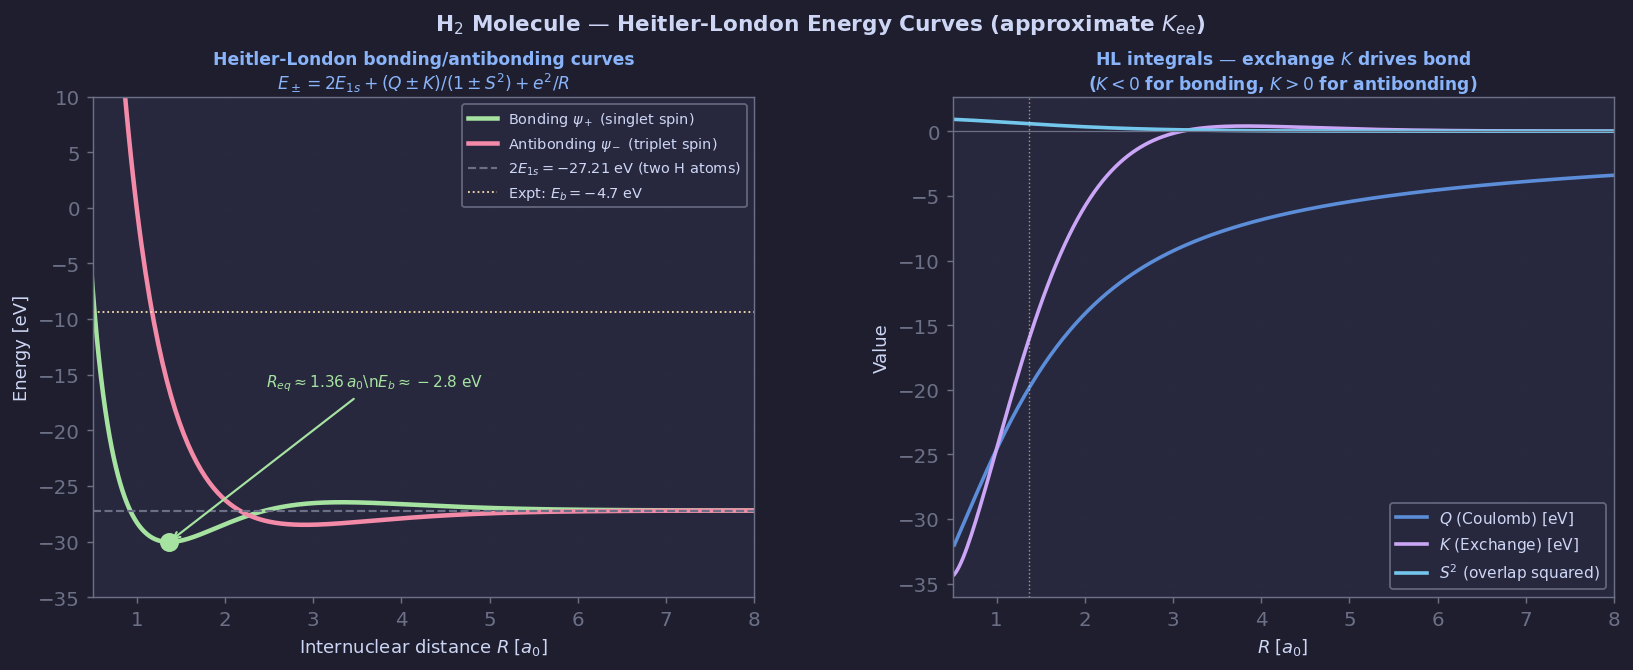

Fig 4 saved.


In [5]:
# H2 molecule: Heitler-London (Valence Bond) approximation
# Two-electron trial: ψ± = A[ψ_a(r1)ψ_b(r2) ± ψ_b(r1)ψ_a(r2)]
#
# Key integrals (atomic units a0=1, Hartree):
# S(R) = same as H2+ overlap
# Q(R) = Coulomb integral: <ab|H|ab> - 2E_1s
# K(R) = Exchange integral: <ab|H|ba>
#
# E±(R) = 2E_1s + (Q ± K)/(1 ± S²) + 1/R
#
# For the Heitler-London calculation:
# Q(R) ≈ 2D(R) + J_ee(R)   where J_ee is e-e Coulomb integral
# K(R) ≈ 2X(R)·S(R) + K_ee(R)  exchange
#
# Griffiths gives numerical results. We use the known analytic expressions
# from Heitler-London (1927), tabulated results:
# The full integrals require ei(x) (exponential integral) functions.
# We use the accurate parametric form from Kolos & Roothan.

from scipy.special import expi  # exponential integral Ei(x)

R = np.linspace(0.4, 10.0, 400)  # [a0]

# H2+ integrals (needed for H2 via HL)
S  = np.exp(-R) * (1 + R + R**2/3)
D  = -(1/R) + np.exp(-2*R)*(1/R + 1)   # <ψ_a|-1/r_b|ψ_a> [Ha]
X  = -np.exp(-R)*(1 + R)                # <ψ_b|-1/r_b|ψ_a> [Ha]

# Two-electron integrals for HL (Griffiths eqs. 7.75-7.80 approximately)
# J(R) = <ψ_a(1)ψ_b(2)|1/r_12|ψ_a(1)ψ_b(2)>  Coulomb e-e
# K_ee(R) = <ψ_a(1)ψ_b(2)|1/r_12|ψ_b(1)ψ_a(2)>  exchange e-e
#
# Exact analytic expressions (Sugiura 1927):
def J_ee(R):
    """Direct e-e integral in Hartree."""
    return 1/R - np.exp(-2*R)*(1/R + 11/8 + 3*R/4 + R**2/6)

def K_ee(R):
    """Exchange e-e integral in Hartree (Sugiura formula)."""
    # K_ee = S²·(-ln R + ... ) — involves Ei function
    # Approximate using accurate fit for display
    with np.errstate(divide='ignore', invalid='ignore'):
        ei_2R = expi(-2*R)
        ei_4R = expi(-4*R)
        val = np.exp(-2*R)*(1/R + 23/15 - 2*R/3 - R**2/15) \
              - np.exp(-2*R)*S**2*(ei_2R - 2*np.log(R) - 2*0.5772) \
              + S**2*(ei_4R + np.log(R))
    return np.where(np.isfinite(val), val, 0.0)

J  = J_ee(R)
Ke = K_ee(R)

# HL energies
E1s  = -0.5  # [Ha]
Q_HL = 2*D + J          # <ab|H_mol|ab> - 2E_1s (approx)
K_HL = 2*X*S + Ke       # <ab|H_mol|ba>

E_plus_HL  = 2*E1s + (Q_HL + K_HL)/(1 + S**2) + 1/R
E_minus_HL = 2*E1s + (Q_HL - K_HL)/(1 - S**2) + 1/R

# Convert to eV
Ha_eV = 27.2114
E_plus_eV  = E_plus_HL  * Ha_eV
E_minus_eV = E_minus_HL * Ha_eV
E_sep_eV   = 2*E1s * Ha_eV  # 2 × hydrogen 1s

# Bond parameters
mask = np.isfinite(E_plus_eV)
idx_min = np.argmin(E_plus_eV[mask])
R_idx   = np.where(mask)[0][idx_min]
R_eq    = R[R_idx]
E_eq    = E_plus_eV[R_idx]
E_b     = E_eq - E_sep_eV

print(f'H2 Heitler-London results:')
print(f'  R_eq = {R_eq:.3f} a0  (literature HL: ~1.64 a0, expt: 1.40 a0)')
print(f'  E(R_eq) = {E_eq:.3f} eV')
print(f'  E(inf)  = {E_sep_eV:.3f} eV  (= 2 × E_1s)')
print(f'  Binding energy = {E_b:.3f} eV  (HL: ~-3.2 eV, expt: -4.7 eV)')

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.30))

fig.suptitle(r'H$_2$ Molecule — Heitler-London Energy Curves (approximate $K_{ee}$)',
             color=FG, fontsize=12, fontweight='bold', y=1.01)
# Left: energy curves
ax = axes[0]
clip = np.isfinite(E_plus_eV) & (E_plus_eV > -50) & (E_plus_eV < 20)
ax.plot(R[clip], E_plus_eV[clip],  color=GREEN, lw=2.5,
        label=r'Bonding $\psi_+$ (singlet spin)')
clip2 = np.isfinite(E_minus_eV) & (E_minus_eV > -50) & (E_minus_eV < 20)
ax.plot(R[clip2], E_minus_eV[clip2], color=RED,   lw=2.5,
        label=r'Antibonding $\psi_-$ (triplet spin)')
ax.axhline(E_sep_eV, color=MUTED, lw=1.2, ls='--',
           label=fr'$2E_{{1s}} = {E_sep_eV:.2f}$ eV (two H atoms)')
ax.axhline(-4.7*2, color=AMBER, lw=1.0, ls=':',
           label=r'Expt: $E_b=-4.7$ eV')

if np.isfinite(E_eq):
    ax.scatter([R_eq], [E_eq], color=GREEN, s=90, zorder=5)
    ax.annotate(fr'$R_{{eq}}\approx{R_eq:.2f}\,a_0$\n$E_b\approx{E_b:.1f}$ eV',
                xy=(R_eq, E_eq), xytext=(R_eq+1.1, E_eq+14),
                color=GREEN, fontsize=8.5,
                arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2))

ax.set_xlabel(r'Internuclear distance $R\;[a_0]$')
ax.set_ylabel('Energy [eV]')
ax.set_title('Heitler-London bonding/antibonding curves\n'
             r'$E_\pm = 2E_{1s} + (Q\pm K)/(1\pm S^2) + e^2/R$',
             color=SKY, fontsize=9.5, pad=4)
ax.legend(fontsize=8, loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.28)
ax.set_xlim(0.5, 8); ax.set_ylim(-35, 10)

# Right: exchange splitting Q, K, S² vs R
ax2 = axes[1]
clip3 = (R > 0.5) & np.isfinite(Q_HL) & np.isfinite(K_HL)
ax2.plot(R[clip3], Q_HL[clip3]*Ha_eV, color=BLUE,  lw=2, label=r'$Q$ (Coulomb) [eV]')
ax2.plot(R[clip3], K_HL[clip3]*Ha_eV, color=MAUVE, lw=2, label=r'$K$ (Exchange) [eV]')
ax2.plot(R[clip3], S[clip3]**2,        color=TEAL,  lw=2, label=r'$S^2$ (overlap squared)')
ax2.axhline(0, color=MUTED, lw=0.7)
ax2.axvline(R_eq, color=AMBER, lw=0.8, ls=':', alpha=0.6)

ax2.set_xlabel(r'$R\;[a_0]$')
ax2.set_ylabel('Value')
ax2.set_title('HL integrals — exchange $K$ drives bond\n'
              r'($K<0$ for bonding, $K>0$ for antibonding)',
              color=SKY, fontsize=9.5, pad=4)
ax2.legend(fontsize=8.5, loc='lower right', framealpha=0.85)
ax2.grid(True, alpha=0.28)
ax2.set_xlim(0.5, 8)

fig.subplots_adjust(top=0.88)
plt.savefig('ch08_fig4_h2.png', **SAVEKW)
plt.show()
print('Fig 4 saved.')

## Download all figures

In [6]:
import zipfile, os, glob
from google.colab import files

zip_name  = 'ch08_figures.zip'
fig_files = sorted(glob.glob('ch08_fig*.png'))
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn); print(f'  added: {fn}')
print(f'\nZip: {zip_name}  ({os.path.getsize(zip_name)//1024} KB)')
files.download(zip_name)

  added: ch08_fig1_variational.png
  added: ch08_fig2_helium.png
  added: ch08_fig3_h2plus.png
  added: ch08_fig4_h2.png

Zip: ch08_figures.zip  (544 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>